<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🚗 Car Price Assignment 💵
    </h1>
</div>


# Overview

**Background**

This dataset contains **car price records** with detailed information on **technical specifications, car company, design attributes, fuel type, and performance indicators**.
It is widely used for **predicting car prices** based on both categorical and numerical features.

Understanding what factors influence a car’s market price (e.g., horsepower, engine size, fuel system, company brand) is valuable for **automobile businesses, dealerships, and customers** to make informed **pricing, purchasing, and valuation decisions**.

**Goal of the Project**

Build a machine learning model to:

* **Predict car prices (in USD)** based on technical and categorical attributes
* Identify **key drivers of price** (engine size, horsepower, brand, fuel type, etc.)
* Provide insights for **automobile pricing strategies** and **customer decision-making**

**Key Features**

| Feature Name       | Description                                          |
| ------------------ | ---------------------------------------------------- |
| `Car_ID`           | Unique identifier for each car                       |
| `carCompany`       | Brand / company of the car (e.g., Toyota, BMW, Audi) |
| `fueltype`         | Type of fuel (gas, diesel)                           |
| `aspiration`       | Aspiration method (std, turbo)                       |
| `doornumber`       | Number of doors                                      |
| `carbody`          | Body style (hatchback, sedan, convertible, etc.)     |
| `drivewheel`       | Type of drive wheel (FWD, RWD, 4WD)                  |
| `enginelocation`   | Location of engine (front, rear)                     |
| `wheelbase`        | Wheelbase length (numeric)                           |
| `carlength`        | Length of car (numeric)                              |
| `carwidth`         | Width of car (numeric)                               |
| `carheight`        | Height of car (numeric)                              |
| `curbweight`       | Weight of car without passengers/baggage             |
| `enginetype`       | Type of engine (ohc, ohcv, dohc, etc.)               |
| `cylindernumber`   | Number of cylinders                                  |
| `enginesize`       | Engine size (numeric)                                |
| `fuelsystem`       | Fuel system (mpfi, 2bbl, etc.)                       |
| `boreratio`        | Bore ratio of engine                                 |
| `stroke`           | Stroke length                                        |
| `compressionratio` | Engine compression ratio                             |
| `horsepower`       | Horsepower (numeric)                                 |
| `peakrpm`          | Peak revolutions per minute                          |
| `citympg`          | Mileage in city                                      |
| `highwaympg`       | Mileage on highway                                   |
| `price`            | Price of car (**target variable**)                   |

**Files Provided**

* [CarPrice_Assignment.csv](https://drive.google.com/file/d/1I-JBEhN0v7GGfdWRan_NNBN660tABIkJ/view)
* [CarPrice_Datadict.pdf](https://drive.google.com/file/d/1Imwscq_1N5SHShVrWxxov8uyEhdBXjqr/view)

**Project Objective**

The goal of this notebook is to **model and predict car prices**, helping to:

* Benchmark car prices across brands and specifications
* Understand which features most strongly affect pricing
* Support **dealers** in competitive pricing strategies
* Assist **customers** in making data-driven purchase decisions

**Key Steps**

* **Exploratory Data Analysis (EDA):** <br>
  Study distribution of car prices by brand, engine size, horsepower, fuel type, and body style.

* **Feature Engineering:**
  Encode categorical variables, normalize numeric features, handle correlations, and derive new variables (e.g., power-to-weight ratio).

* **Modeling:**
  Train and compare multiple models:

  * Linear Regression
  * Random Forest Regressor
  * Gradient Boosting (XGBoost, LightGBM)
  * Ensemble approaches

* **Evaluation Framework:**
  Use cross-validation and evaluate with:

  * RMSE (Root Mean Squared Error)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [33]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical functions
from scipy.stats import skew

# Display utilities for Jupyter notebooks
from IPython.display import display

# Machine learning preprocessing and modeling
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import shapiro, probplot
from scipy.stats import mannwhitneyu
from scipy.stats import levene
from scipy.stats import ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
from scipy.stats import anderson
import scikit_posthocs as sp
from scipy.stats import normaltest

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [34]:
link = "https://drive.google.com/file/d/1I-JBEhN0v7GGfdWRan_NNBN660tABIkJ/view"
path = "https://drive.google.com/uc?id=" + link.split("/")[-2]
df = pd.read_csv(path)

# Verify shapes
print("Data Shape:", df.shape)

Data Shape: (205, 26)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [35]:
# Display few rows of dataset
print("Data Preview:")
display(df.head())

Data Preview:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [36]:
# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null   

## Insights from Initial Data Exploration

**Dataset Size and Structure**

* The dataset contains **205 observations (samples)** with **26 columns**, including the target variable `price`.
* The columns consist of **8 integer (int64)** variables, **8 float (float64)** variables, and **10 categorical (object)** variables.

**Feature Overview**

* **Numerical features:**

  * Related to dimensions, weight, power, and performance:

    * `wheelbase`, `carlength`, `carwidth`, `carheight`, `curbweight`, `enginesize`, `boreratio`, `stroke`, `compressionratio`, `horsepower`, `peakrpm`, `citympg`, `highwaympg`, `price`.
  * These represent the technical factors that directly influence car price.

* **Categorical features:**

  * Related to brand, design, and configuration:

    * `CarName`, `fueltype`, `aspiration`, `doornumber`, `carbody`, `drivewheel`, `enginelocation`, `enginetype`, `cylindernumber`, `fuelsystem`.
  * These variables help the model capture differences in price based on brand, body style, and engine technology.

* **Target variable:**

  * `price` (float64): car price – a continuous numerical variable.

**Data Completeness**

* Data types are appropriate:

  * **Categorical:** object.
  * **Numerical:** int64 or float64.
* This makes the **preprocessing step** straightforward, requiring only encoding for categorical variables and scaling for numerical ones.

In [37]:
df.columns = (df.columns.str.strip())

df.drop(columns="car_ID", axis=1, inplace=True)

# Display few rows of dataset
print("Data Preview:")
display(df.head())

Data Preview:


,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [38]:
num_features = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "boreratio", "stroke",
                "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg"]

print("Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

Data describe:


,count,mean,std,min,25%,50%,75%,max
wheelbase,205.000000,98.756585,6.021776,86.600000,94.500000,97.000000,102.400000,120.900000
carlength,205.000000,174.049268,12.337289,141.100000,166.300000,173.200000,183.100000,208.100000
carwidth,205.000000,65.907805,2.145204,60.300000,64.100000,65.500000,66.900000,72.300000
carheight,205.000000,53.724878,2.443522,47.800000,52.000000,54.100000,55.500000,59.800000
curbweight,205.000000,2555.565854,520.680204,1488.000000,2145.000000,2414.000000,2935.000000,4066.000000
enginesize,205.000000,126.907317,41.642693,61.000000,97.000000,120.000000,141.000000,326.000000
boreratio,205.000000,3.329756,0.270844,2.540000,3.150000,3.310000,3.580000,3.940000
stroke,205.000000,3.255415,0.313597,2.070000,3.110000,3.290000,3.410000,4.170000
compressionratio,205.000000,10.142537,3.972040,7.000000,8.600000,9.000000,9.400000,23.000000
horsepower,205.000000,104.117073,39.544167,48.000000,70.000000,95.000000,116.000000,288.000000


## Descriptive Insights – Numerical Features

* **Dataset size:** 205 cars, 13 main numerical features + target `price`.

**Car Specifications**

* **Dimensions:**

  * Wheelbase: 86.6 → 120.9 (mean ~98.8)
  * Car length: 141 → 208 (mean ~174)
  * Car width: 60 → 72 (mean ~65.9)
* **Weight (curbweight):** 1488 → 4066, average ~2556

**Engine & Performance**

* Engine size: 61 → 326 (mean ~127)
* Horsepower: 48 → 288 (mean ~104)
* Peak RPM: 4150 → 6600 (mean ~5125)
* City MPG: 13 → 49 (mean ~25)
* Highway MPG: 16 → 54 (mean ~30.8)

**Key insight:**

* Small dataset (205 cars) but diverse in specifications.
* Technical specs (engine size, horsepower, mpg) span wide ranges, making them useful predictors of price.

In [39]:
# We need to group some features to make the analysis easier.
# brand_grouped
df["brand_raw"] = df["CarName"].astype(str).str.strip().str.split().str[0].str.lower()

# Normalization mapping for typos/aliases
brand_map = {
    "vw": "volkswagen",
    "vokswagen": "volkswagen",
    "volkswagon": "volkswagen",
    "toyouta": "toyota",
    "porcshce": "porsche",
    "maxda": "mazda",
    "alfa-romero": "alfa-romeo",
    "sabaru": "subaru",
    "saboru": "subaru"
}

# Apply normalization into a clean brand column
df["brand"] = df["brand_raw"].map(brand_map).fillna(df["brand_raw"])

brand_counts = df["brand"].value_counts()
common_brands = brand_counts[brand_counts >= 10].index
df["brand_grouped"] = df["brand"].apply(lambda x: x if x in common_brands else "Other")
df["brand_grouped"].value_counts()
df.drop(columns=["brand_raw", "brand", "CarName"])

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand_grouped
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,Other
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,Other
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,Other
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,Other
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,-1,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,-1,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [40]:
# symboling_group
# Mapping symboling into 3 groups
symboling_map = {
    -3: "Safe",
    -2: "Safe",
    -1: "Safe",
     0: "Neutral",
     1: "Risky",
     2: "Risky",
     3: "Risky"
}

# Apply mapping
df["symboling_group"] = df["symboling"].map(symboling_map)

df = df.drop(columns=["symboling"])
# Kiểm tra phân phối
print(df["symboling_group"].value_counts())

symboling_group
Risky      113
Neutral     67
Safe        25
Name: count, dtype: int64


In [41]:
cat_features = ["brand_grouped", "symboling_group", "fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", 
                "enginetype", "cylindernumber", "fuelsystem"]
def convert_cat(df, cat_features= cat_features):
    for feature in cat_features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
        else:
            pass

convert_cat(df=df)
print("Data describe:")
df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"])

Data describe:


,count,unique,top,freq
brand_grouped,205,10,Other,66
symboling_group,205,3,Risky,113
fueltype,205,2,gas,185
aspiration,205,2,std,168
doornumber,205,2,four,115
carbody,205,5,sedan,96
drivewheel,205,3,fwd,120
enginelocation,205,2,front,202
enginetype,205,7,ohc,148
cylindernumber,205,7,four,159


## Categorical Feature Summary – Car Price Dataset

* **Brand (brand_grouped):**

  * 10 groups (9 major brands + “Other”)
  * **Other** has the largest share (66 samples) → includes rare brands.

* **Symboling Group:**

  * 3 risk levels: **Risky (113)**, Neutral, Safe
  * **Risky cars** account for more than **50%** of the dataset.

* **Fueltype:**

  * 2 categories: **Gas (185)** dominates, Diesel is very limited (**20**).

* **Aspiration:**

  * **Std (168)** is more common, Turbo only (**37**).

* **Doornumber:**

  * 2 categories: **Four doors (115)** more frequent than Two doors.

* **Carbody:**

  * 5 body styles, with **Sedan (96)** being the most common.

* **Drivewheel:**

  * 3 categories, **FWD (120)** dominates → most cars are front-wheel drive.

* **Engine Location:**

  * Almost all are **Front (202)**, very few with rear engines.

* **Enginetype:**

  * 7 engine types, **OHC (148)** is the majority.

* **Cylinder Number:**

  * 7 categories, **Four cylinders (159)** most frequent.

* **Fuelsystem:**

  * 8 categories, with **MPFI (94)** most common.

👉 **Key takeaways for slides:**

* Dataset is diverse in brand, body style, and engine → suitable for analyzing price impact.
* Several categorical features are clearly **imbalanced** (e.g., **Gas**, **Front engine**, **OHC**, **4 cylinders** dominate).
* These imbalances may affect modeling → need attention when encoding or analyzing.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [42]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    missing_df = df.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
✅ No missing values detected in 205 rows.


## Checking duplicate Value

In [43]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Data": df
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Data Duplicate Analysis
✅ No duplicates found in 205 rows


## Checking Outlier Value

In [44]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,wheelbase,3
1,carlength,1
2,carwidth,8
3,enginesize,10
4,stroke,20
5,compressionratio,28
6,horsepower,6
7,peakrpm,2
8,citympg,2
9,highwaympg,3


## Data Quality Insights: Missing Values, Duplicates and Outliers

**Missing Values Analysis**

- We conducted a thorough check for missing values in the datasets.  
- **No missing values** in the datasets.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

  * **No duplicates** detected in 205 rows — ensuring test predictions are made on unique samples.

**Outliers Records Analysis**

- We also examined the datasets for checking outliers.
- **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.

**Conclusion**

* The dataset demonstrates **excellent data quality** with **no missing values** and **no duplicate records**, ensuring reliable inputs for analysis and modeling.
* **Outliers are present** in features such as `wheelbase`, `enginesize`, `compressionratio`,... but they represent realistic variations in financial transactions and should not be removed outright.
* Overall, the dataset is **well-prepared for modeling**, requiring only standard preprocessing steps (e.g., encoding categorical variables, scaling numerical features, and handling outliers carefully if needed).

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [45]:
def color(n_colors=2):
    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    positions = np.linspace(0, 1, n_colors)
    colors = [cmap(p) for p in positions]
    return colors

In [46]:
def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """

    groups = dataframe[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Mann-Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    print(f"🔍 Mann–Whitney U Test for '{num_feature}' by '{categorical_feature}'\n")
    print("H₀: The distributions of the two groups are equal.")
    print("H₁: The distributions are different.\n")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"U statistic : {stat}")
    print(f"p-value     : {p}")

    # Interpretation
    if p <= 0.05:
        print("\n✅ Result: Statistically significant difference between the two groups (Reject H₀).")
        median1 = group1.median()
        median2 = group2.median()
        if median1 > median2:
            print(f" Interpretation: Group '{groups[0]}' has a higher median '{num_feature}' than Group '{groups[1]}'.")
        elif median1 < median2:
            print(f" Interpretation: Group '{groups[1]}' has a higher median '{num_feature}' than Group '{groups[0]}'.")
        else:
            print(" Interpretation: The medians are equal, but distributions may still differ.")
    else:
        print("\n⚪ Result: No statistically significant difference between the two groups (Fail to reject H₀).")

def perform_kruskal_test(df, categorical_feature, numeric_feature):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically 
    significant differences in the distribution of a numeric variable across 
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction 
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and 
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        print(f"❌ Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        print(f"p-value: {p}")
        
        if p < 0.05:
            print("🟢 Significant difference found. Running Dunn's Post-Hoc Test...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def cal_normaltest(cat_feature, num_feature, df):
    """
    Perform D’Agostino and Pearson’s normality test on a numerical feature 
    across groups defined by a categorical feature.

    Parameters
    ----------
    cat_feature : str
        The name of the categorical column that defines the groups.

    num_feature : str
        The name of the numerical column to test for normality.

    df : pd.DataFrame
        The input DataFrame containing the data.

    Returns
    -------
    None
        Prints the test statistic and p-value for each group.

    Notes
    -----
    - H₀ (null hypothesis): The data is normally distributed.
    - H₁ (alternative): The data is not normally distributed.
    - If p > 0.05 → fail to reject H₀ → data appears normal.
    - If p ≤ 0.05 → reject H₀ → data likely not normal.
    - Recommended for n ≥ 20, especially reliable for n > 50.
    - Requires at least 8 non-null values per group (as per scipy recommendation).
    """
    
    print(f"🔎 D’Agostino and Pearson Normality Test for '{num_feature}' across '{cat_feature}' groups\n")

    for group in df[cat_feature].dropna().unique():
        data = df[df[cat_feature] == group][num_feature].dropna()
        n = len(data)

        print(f" Group: {group} (n = {n})")
        
        if n < 8:
            print(f"⚠️ Too few observations (< 8) to perform the test.\n")
            continue

        stat, p = normaltest(data)

        print(f"  Statistic : {stat:.3f}")
        print(f"  p-value   : {p:.5f}")
        
        if p > 0.05:
            print(f"  🟢 Interpretation: Data appears to follow a normal distribution.\n")
        else:
            print(f"  🔴 Interpretation: Data does not appear to follow a normal distribution.\n")

##  Price Distribution

In [47]:
df.columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'price', 'brand_raw', 'brand',
       'brand_grouped', 'symboling_group'],
      dtype='object')

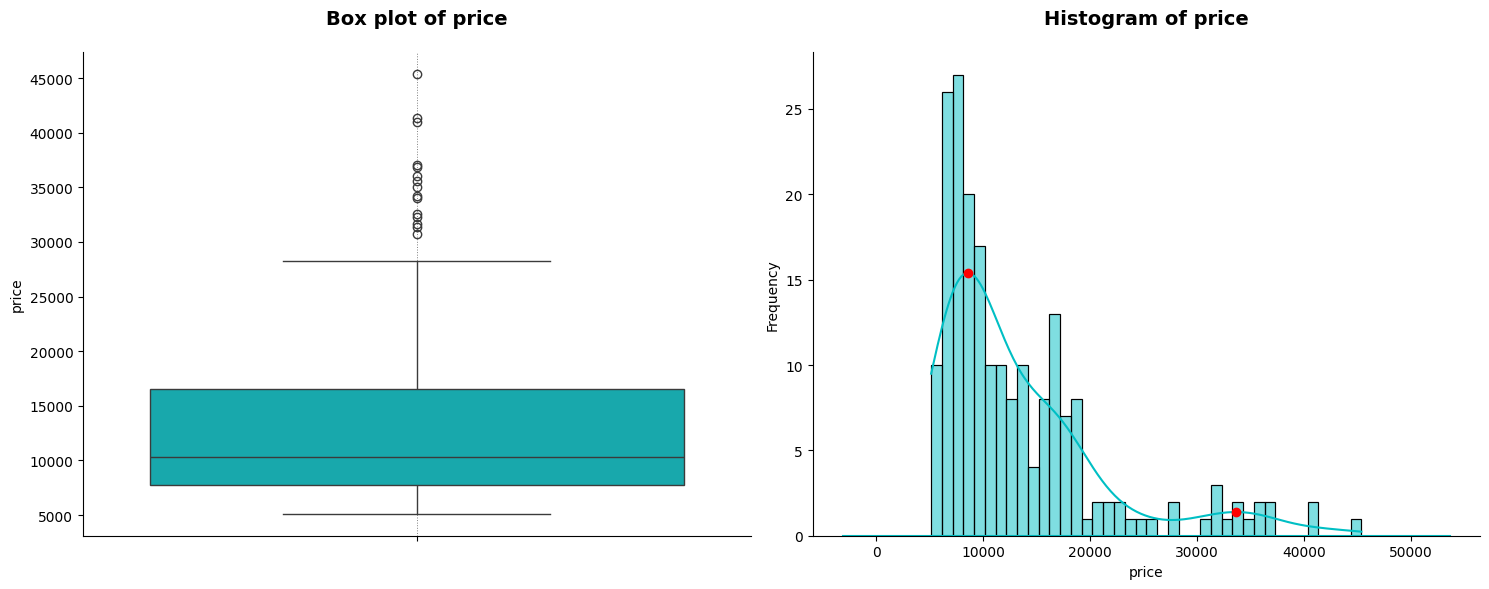

In [48]:
from scipy.signal import find_peaks
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 6))

sns.boxplot(data=df, y = "price", ax=ax[0], color="#00BFC4")
ax[0].set_title(f"Box plot of price", fontsize=14, pad=20, weight="bold")
ax[0].grid(axis="x", color="gray", linestyle=":", linewidth=0.7)
ax[0].set_ylabel("price")
sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

sns.histplot(data=df, x = "price", ax=ax[1], color="#00BFC4", kde=True, bins=40)
ax[1].set_title(f"Histogram of price", fontsize=14, pad=20, weight="bold")
ax[1].set_xlabel("price")
ax[1].set_ylabel("Frequency")
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

# Extract KDE values to find peaks
kde = sns.kdeplot(df["price"], ax=ax[1], color="#00BFC4").lines[0].get_data()
kde_x, kde_y = kde[0], kde[1]
peaks, _ = find_peaks(kde_y)

# Highlight peaks
for peak_idx in peaks:
    plt.plot(kde_x[peak_idx], kde_y[peak_idx], "ro")  # Red dots on peaks

plt.tight_layout()
plt.show()

**Price Distribution Overview**

* **Range:** Car prices range from approximately **5,000 → 45,000 USD**.
* **Median:** ~10,000 USD → most cars fall into the low-to-mid price segment.
* **IQR (25% – 75%):** ~8,000 → 16,500 USD → over 50% of cars are within this range.
* **Outliers:** Several high-priced cars (**>30,000 USD**) are clearly visible in the boxplot.
* **Shape:** The histogram is **right-skewed** → many low-priced cars, with a few luxury models stretching the distribution to the right.

👉 **Key takeaway for slides:**

* The dataset mainly represents **low to mid-priced cars**.
* There are **significant outliers** in the luxury segment, which may skew the data and should be considered in modeling.

## Numerical Feature Distributions

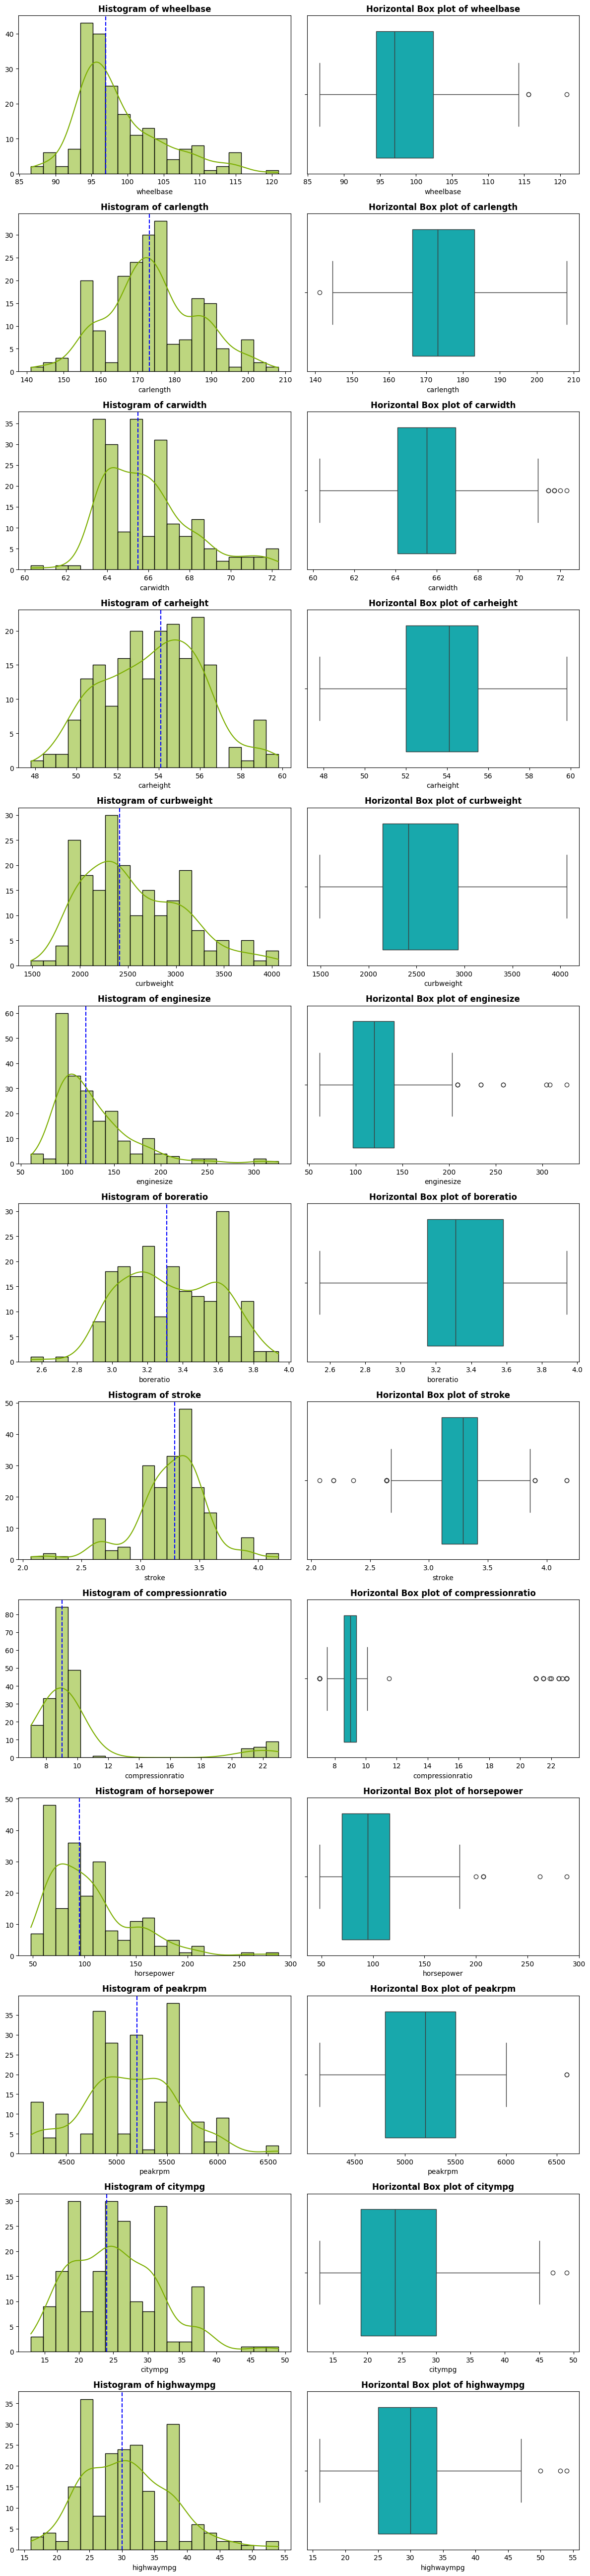

In [49]:
def plot_numerical_features(df=df, numerical_features = num_features):
    fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    axes = np.atleast_2d(axes)

    for i, feature in enumerate(numerical_features):
        sns.histplot(data=df[feature], color="#7CAE00", bins = 20, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f"Histogram of {feature}", weight="bold")
        axes[i, 0].set_ylabel("")
        axes[i, 0].axvline(df[feature].median(), color="blue", linestyle="--", label="Median Train")

        sns.boxplot(data=df[feature], color="#00BFC4", orient="h", ax=axes[i, 1])
        axes[i, 1].set_title(f"Horizontal Box plot of {feature}", weight="bold")
        axes[i, 1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [50]:
num_features = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "boreratio", "stroke",
                "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg", "price"]
def check_skewness(data = df, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\n🔍 Skewness for dataset:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+10f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
compressionratio               |  +2.610862 | Highly skewed
enginesize                     |  +1.947655 | Highly skewed
price                          |  +1.777678 | Highly skewed
horsepower                     |  +1.405310 | Highly skewed
wheelbase                      |  +1.050214 | Highly skewed
carwidth                       |  +0.904003 | Moderately skewed
stroke                         |  -0.689705 | Moderately skewed
curbweight                     |  +0.681398 | Moderately skewed
citympg                        |  +0.663704 | Moderately skewed
highwaympg                     |  +0.539997 | Moderately skewed
carlength                      |  +0.155954 | Approximately symmetric
peakrpm                        |  +0.075159 | Approximately symmetric
carheight           

### Insights on Numerical Feature Distributions

* Key technical variables (**engine size, horsepower, price,...**) show **high skewness**, which may impact regression models.
* Several **outliers** are present (visible in boxplots of enginesize, horsepower, compressionratio).
* Consider **log transformation**, **Box-Cox**,... to address skewness before modeling.
* Nearly normal features (carlength, peakrpm, carheight, boreratio) can be used directly without transformation.

## Correlation Analysis of Numerical Features

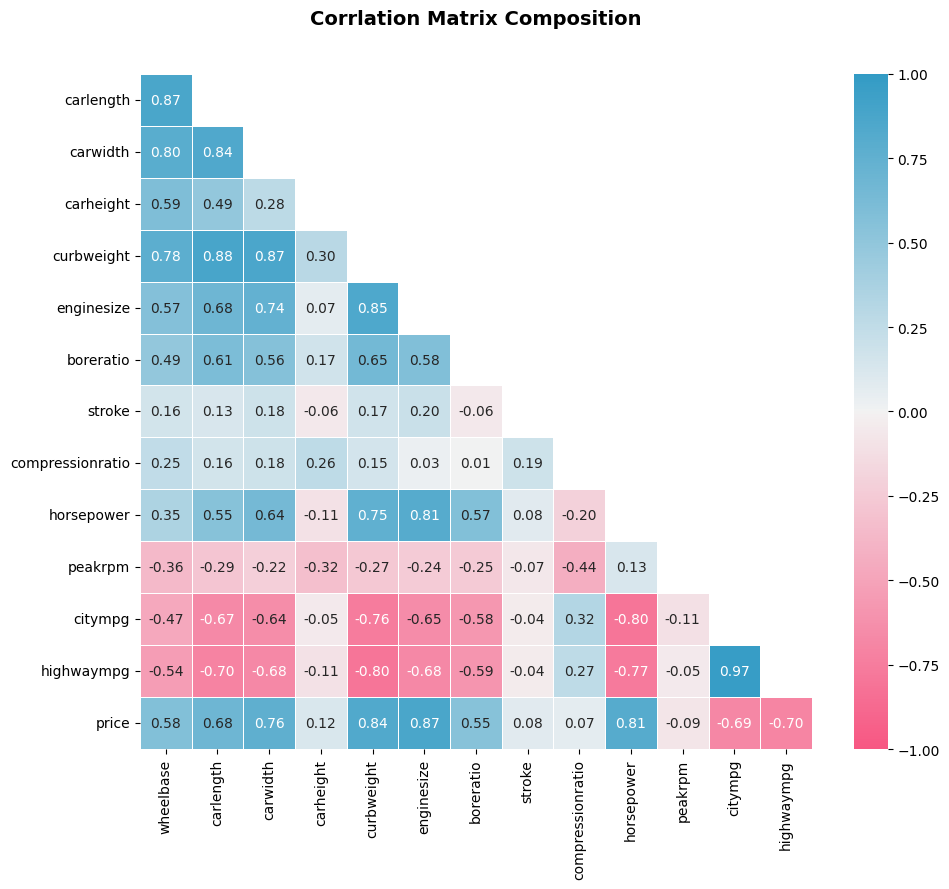

In [51]:
corr_matrix = df.drop(columns=cat_features, axis=1).corr(numeric_only=True)
# one_like can build a matrix of boolean(True, False) with the same shape as our data
ones_corr = np.ones_like(corr_matrix, dtype=bool)
mask = np.triu(ones_corr)
adjusted_mask = mask[1:, :-1]
adjusted_cereal_corr = corr_matrix.iloc[1:, :-1]

fig, ax = plt.subplots(figsize = (10, 9))
# That method uses HUSL colors, so you need hue, saturation, and lightness. 
# I used hsluv.org to select the colors of this chart.
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

sns.heatmap(data=adjusted_cereal_corr, mask=adjusted_mask,
            annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, linecolor="white", linewidths=0.5)

title = "Corrlation Matrix Composition\n"
ax.set_title(title, loc="center", fontsize=14, weight="bold", pad=20)

plt.tight_layout()
plt.show()

### **Insights from Correlation Analysis of Numerical Features**

**Strong Positive Correlations with `price`**

* **Curbweight (0.84), Enginesize (0.82), Horsepower (0.81), Carwidth (0.76)**
  → Heavier cars with larger engines, higher horsepower, and wider bodies tend to be more expensive.
* **Carlength (0.71), Wheelbase (0.58)** also show notable positive correlation with price.

**Negative Correlations with `price`**

* **Citympg (-0.69), Highwaympg (-0.70)**
  → Cheaper cars are generally more fuel-efficient, while expensive cars consume more fuel.

**Multicollinearity**

* Strong correlations exist among technical features:

  * `carlength` ↔ `curbweight` (0.87)
  * `enginesize` ↔ `curbweight` (0.85)
  * `citympg` ↔ `highwaympg` (0.97)
* ⇒ Risk of **multicollinearity** in linear regression. Feature selection or models less sensitive to multicollinearity (e.g., tree-based methods) should be considered.

**Key Takeaways for Slides**

* Car price is strongly driven by **power and size features** (engine size, horsepower, curb weight).
* Expensive cars tend to be **less fuel-efficient**.
* Multicollinearity among technical features needs to be addressed to ensure robust modeling:
    - We will use Ridge or Lasso can reduce the impact of multicollinearity.
    - Ensemble tree-based models such as Random Forest, XGBoost, and LightGBM,... are generally less sensitive to multicollinearity.

## Categorical Feature Distributions

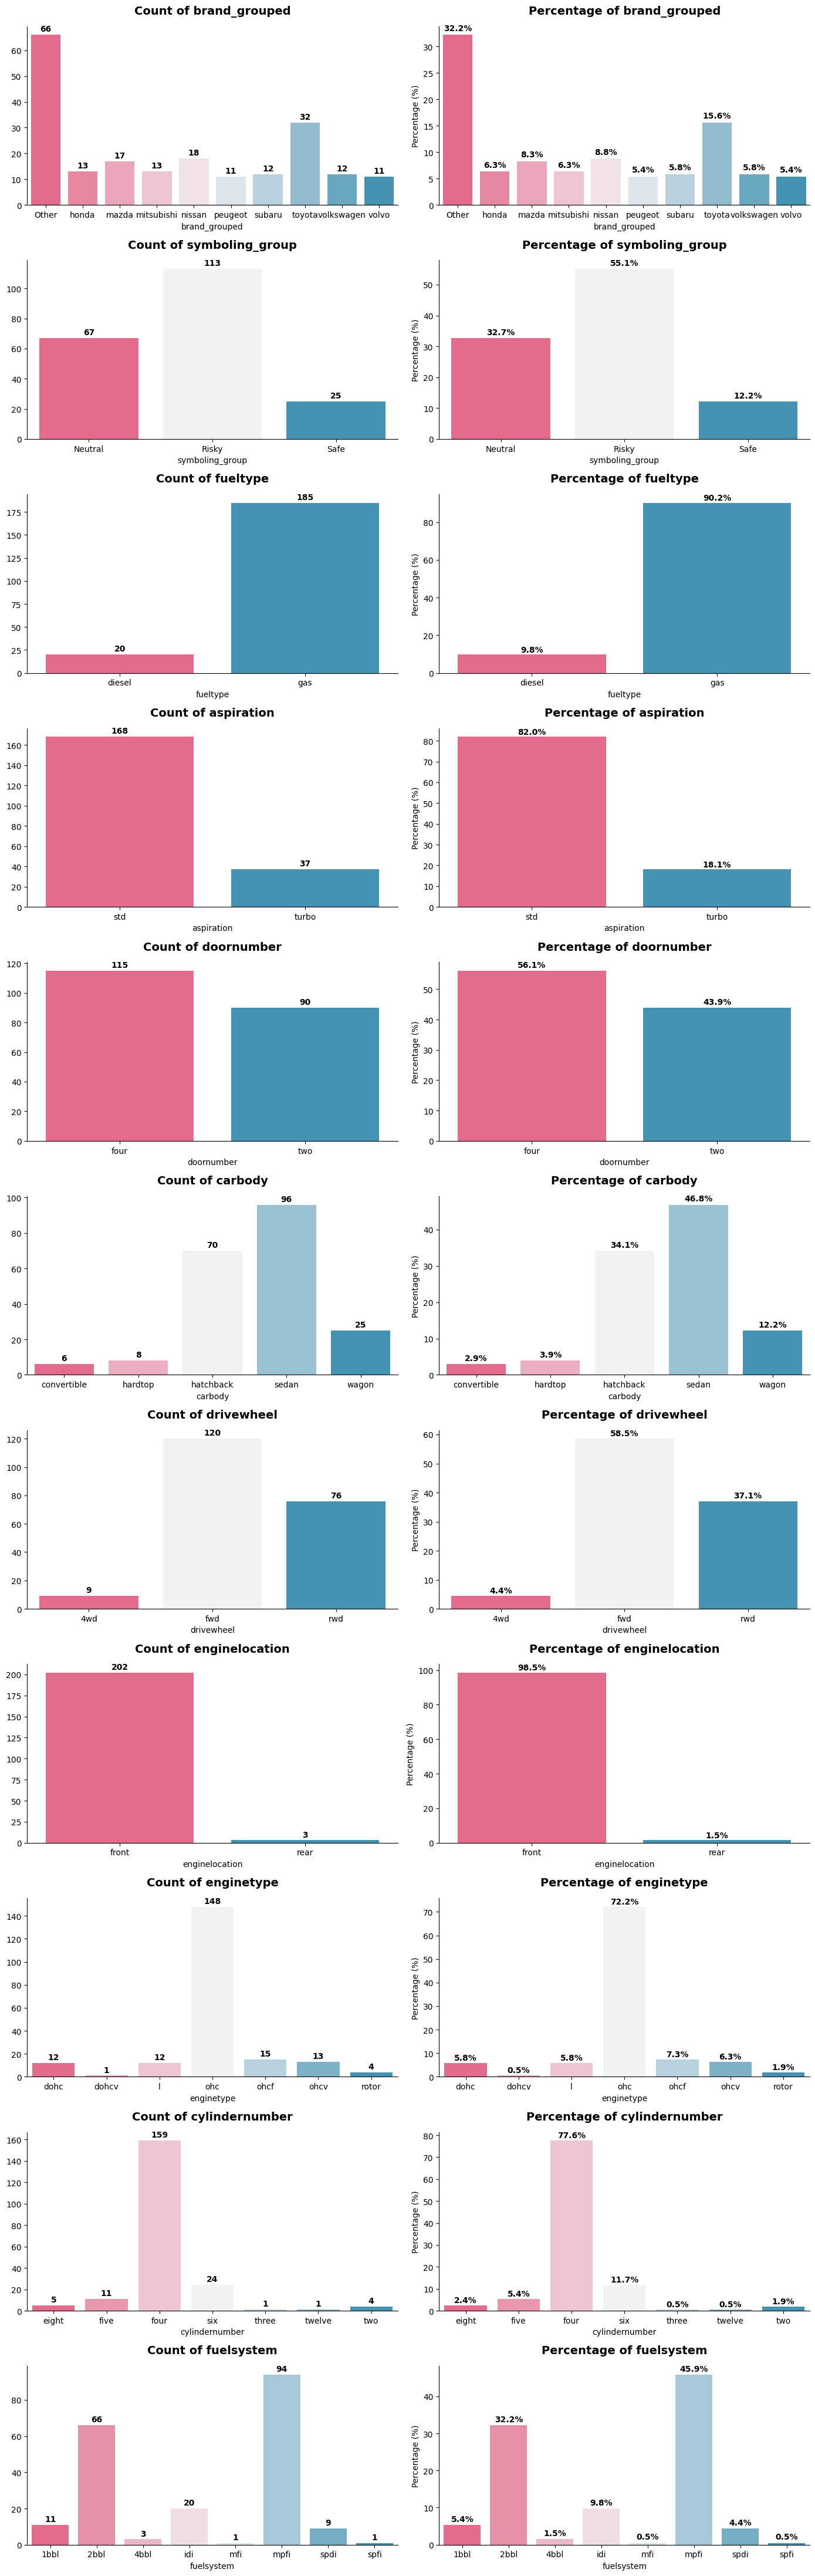

In [52]:
def plot_categorical_distribution(df, cat_features):
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(14, len(cat_features)*4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        # ----------------------------
        # LEFT: Vertical Countplot
        # ----------------------------
        sns.countplot(data=df, x=feature, ax=ax[i, 0],
                      palette=color(n_colors=len(df[feature].unique())))
        
        ax[i, 0].set_title(f"Count of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        if feature == "job_category":
            ax[i, 0].set_xticklabels(labels = ax[i, 0].get_xticklabels(), rotation = 30)
        ax[i, 0].set_ylabel("")
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels on top
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}",
                          ha="center", va="bottom", fontsize=10, fontweight="bold")

        # ----------------------------
        # RIGHT: Barplot with % labels
        # ----------------------------
        feature_counts = df[feature].value_counts(normalize=True).sort_index()
        percentage_df = feature_counts.mul(100).round(2).reset_index()
        percentage_df.columns = [feature, "Percentage"]

        sns.barplot(data=percentage_df, x=feature, y="Percentage",
                    ax=ax[i, 1],
                    palette=color(n_colors=len(feature_counts)))
        
        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 1].set_ylabel("Percentage (%)")
        if feature == "job_category":
            ax[i, 1].set_xticklabels(labels = ax[i, 1].get_xticklabels(), rotation = 30)
        ax[i, 1].set_xlabel(feature)
        sns.despine(ax=ax[i, 1], top=True, right=True)

        # Add % labels on top
        for p in ax[i, 1].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 1].text(x, height + 0.5,
                          f"{height:.1f}%",
                          ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df=df, cat_features=cat_features)

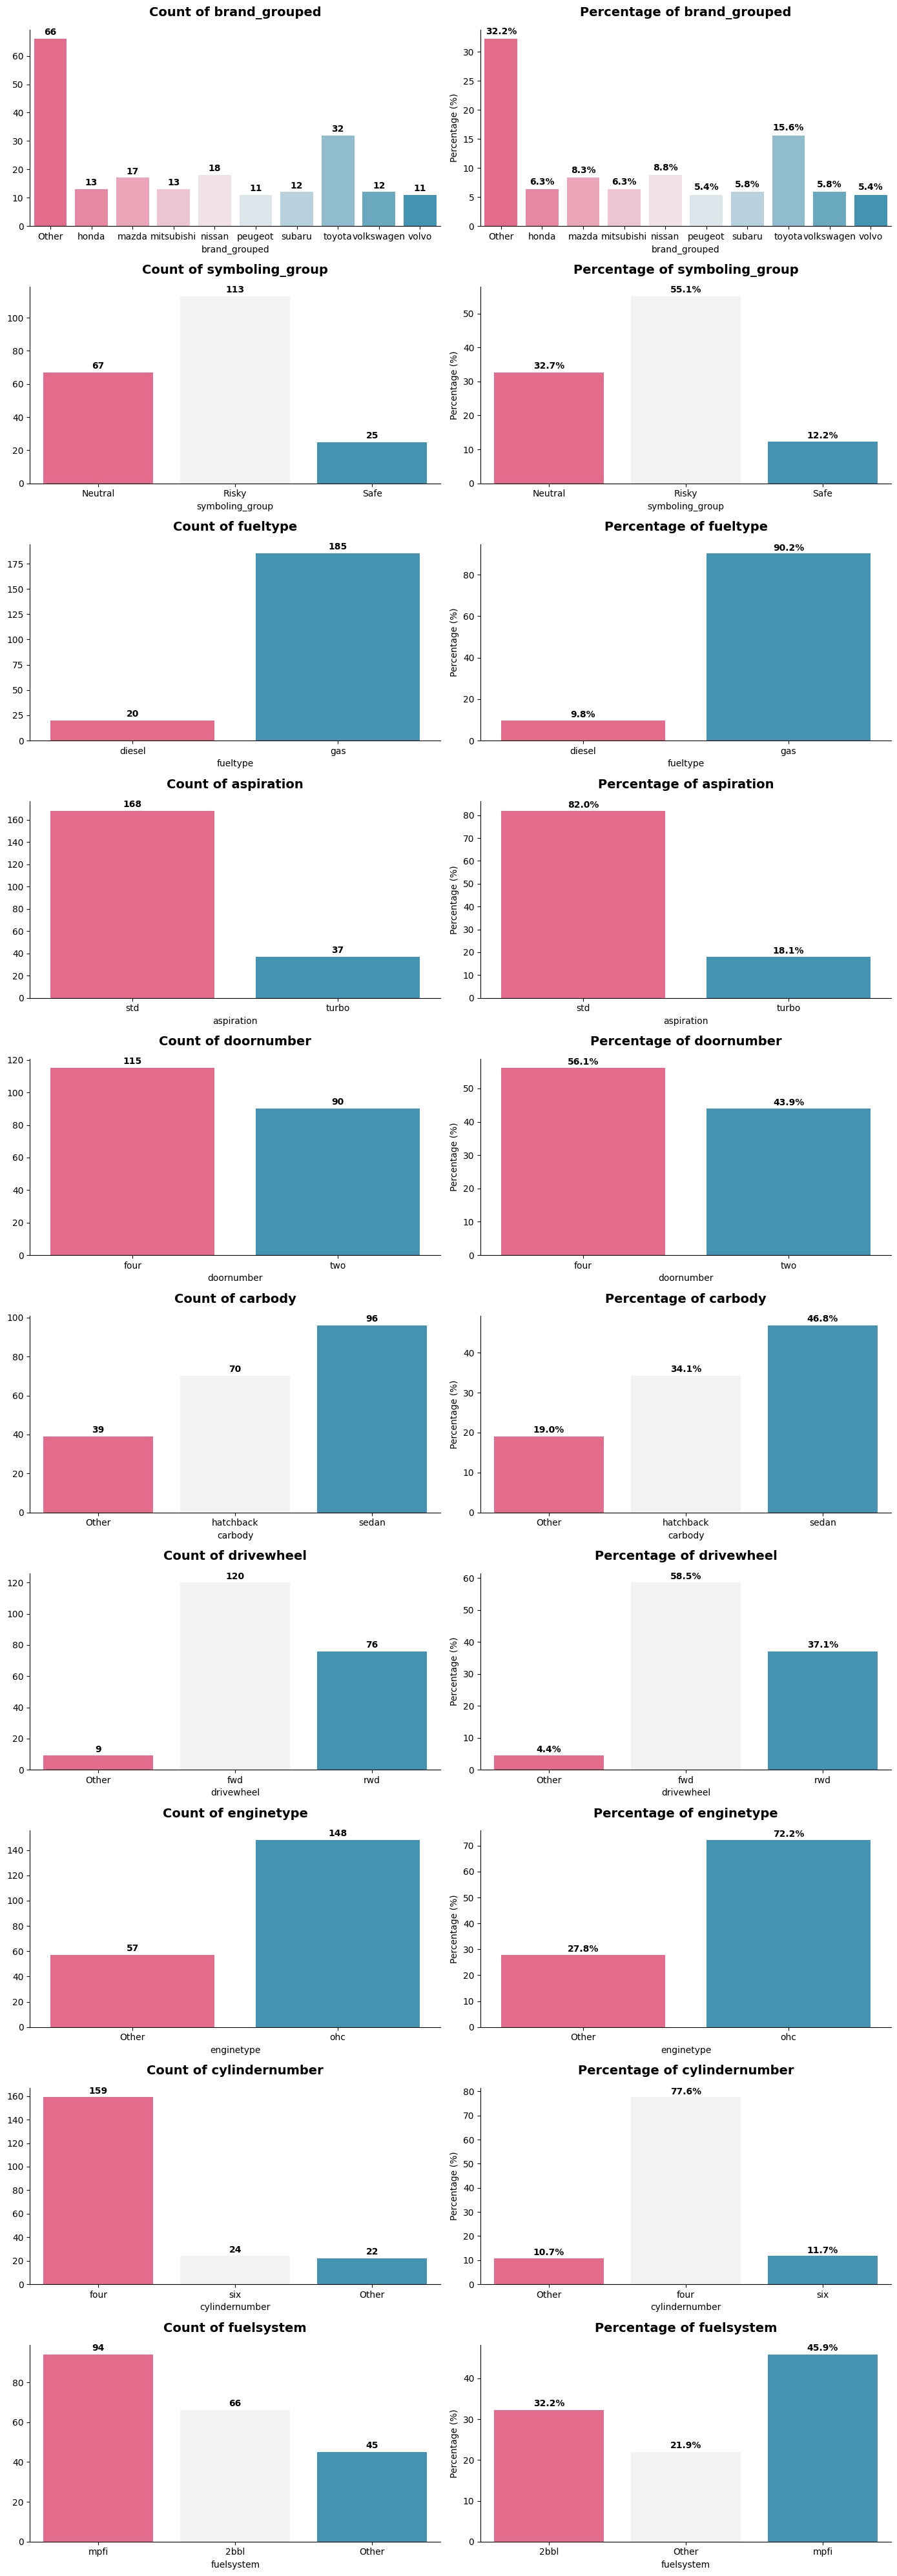

In [53]:
# carbody: keep sedan, hatchback; group the rest into Other
df["carbody"] = df["carbody"].apply(lambda x: x if x in ["sedan", "hatchback"] else "Other")

# drivewheel: keep fwd, rwd; group 4wd into Other
df["drivewheel"] = df["drivewheel"].apply(lambda x: x if x in ["fwd", "rwd"] else "Other")

# enginelocation: drop completely (almost all are front, rear is very rare)
df = df.drop(columns=["enginelocation"])

# enginetype: keep ohc, group the rest into Other
df["enginetype"] = df["enginetype"].apply(lambda x: x if x == "ohc" else "Other")

# cylindernumber: keep four, six; group the rest into Other
df["cylindernumber"] = df["cylindernumber"].apply(lambda x: x if x in ["four", "six"] else "Other")

# fuelsystem: keep mpfi, 2bbl; group the rest into Other
df["fuelsystem"] = df["fuelsystem"].apply(lambda x: x if x in ["mpfi", "2bbl"] else "Other")

cat_features = ["brand_grouped", "symboling_group", "fueltype", "aspiration", "doornumber", "carbody", "drivewheel", 
                "enginetype", "cylindernumber", "fuelsystem"]

plot_categorical_distribution(df=df, cat_features=cat_features)

### Insight on categorical Feature Distribution

* **Brand (brand_grouped):**

  * “Other” remains the largest (**32%**), followed by Honda, Toyota, Mazda, Mitsubishi, Nissan…
  * Balanced overall, without too many small rare groups.

* **Symboling Group:**

  * Risky (**55%**), Neutral (**33%**), Safe (**12%**) → skewed toward Risky.

* **Fueltype:**

  * Gas dominates (**90%**), Diesel only (**10%**).

* **Aspiration:**

  * Std (**82%**) far more common than Turbo (**18%**).

* **Doornumber:**

  * Four doors (**56%**) vs Two doors (**44%**) → relatively balanced.

* **Carbody (grouped):**

  * Sedan (**47%**) and Hatchback (**34%**) dominate, others grouped into “Other” (**19%**).

* **Drivewheel (grouped):**

  * FWD (**59%**) most common, RWD (**37%**), Other (4WD) only **4%**.

* **Enginetype (grouped):**

  * OHC (**72%**) dominant, all others grouped into “Other” (**28%**).

* **Cylindernumber (grouped):**

  * Four cylinders (**78%**), Six (**12%**), Other (**11%**).

* **Fuelsystem (grouped):**

  * MPFI (**46%**) and 2bbl (**32%**) dominate, Other ~**22%**.

## Bivariate Analysis

,brand_grouped,Count,Mean_target_feature,Median_target_feature,Std_target_feature
0,Other,66,18451.222227,16465.000000,11125.314119
9,volvo,11,18063.181818,18420.000000,3314.650263
5,peugeot,11,15489.090909,16630.000000,2246.749673
2,mazda,17,10652.882353,10595.000000,3975.682094
4,nissan,18,10415.666667,8124.000000,4477.394200
8,volkswagen,12,10077.500000,9737.500000,2178.549872
7,toyota,32,9885.812500,9103.000000,3204.982114
3,mitsubishi,13,9239.769231,8499.000000,3042.998690
6,subaru,12,8541.250000,7894.000000,1940.191468
1,honda,13,8184.692308,7295.000000,2061.672112


🔎 D’Agostino and Pearson Normality Test for 'price' across 'brand_grouped' groups

 Group: Other (n = 66)
  Statistic : 7.689
  p-value   : 0.02139
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: honda (n = 13)
  Statistic : 3.741
  p-value   : 0.15408
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: mazda (n = 17)
  Statistic : 1.728
  p-value   : 0.42153
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: mitsubishi (n = 13)
  Statistic : 1.973
  p-value   : 0.37287
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: nissan (n = 18)
  Statistic : 3.489
  p-value   : 0.17473
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: peugeot (n = 11)
  Statistic : 2.376
  p-value   : 0.30477
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: subaru (n = 12)
  Statistic : 0.160
  p-value   : 0.92320
  🟢 Interpretation: Data appears to follow 

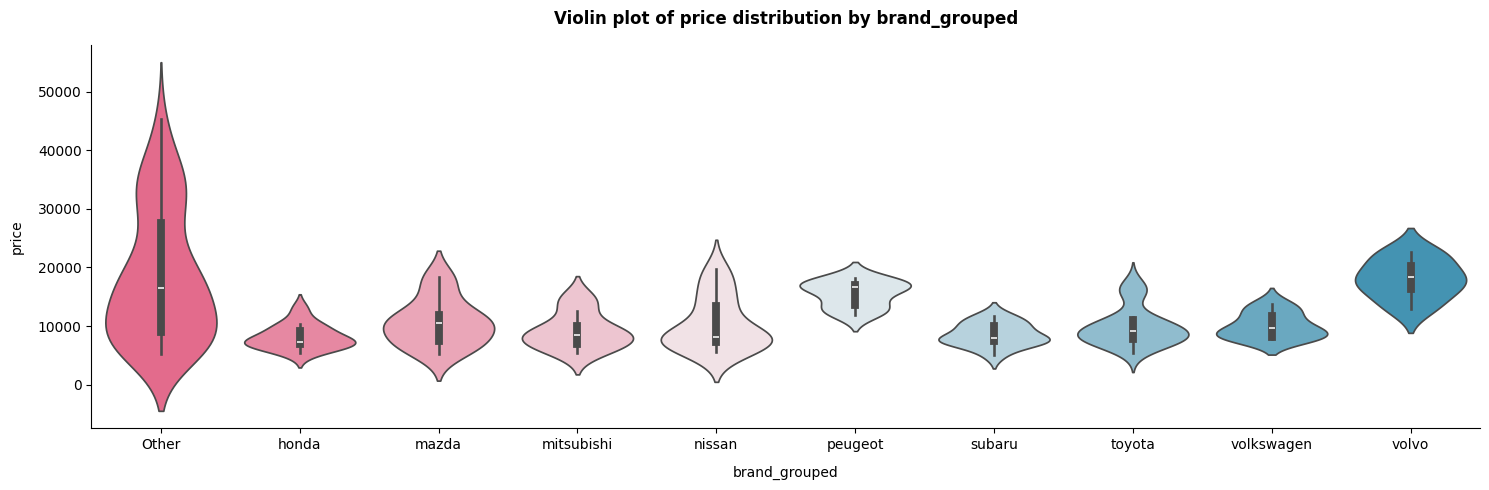

,symboling_group,Count,Mean_target_feature,Median_target_feature,Std_target_feature
2,Safe,25,17144.800000,15985.000000,7209.235240
0,Neutral,67,14366.965179,11259.000000,8752.400937
1,Risky,113,11774.504425,8916.500000,7323.943081


🔎 D’Agostino and Pearson Normality Test for 'price' across 'symboling_group' groups

 Group: Risky (n = 113)
  Statistic : 65.939
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: Neutral (n = 67)
  Statistic : 29.100
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: Safe (n = 25)
  Statistic : 3.375
  p-value   : 0.18494
  🟢 Interpretation: Data appears to follow a normal distribution.


🔍 Kruskal-Wallis Test: price ~ symboling_group
Kruskal-Wallis H-statistic: 21.542
p-value: 2.099867246055775e-05
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
          Neutral     Risky      Safe
Neutral  1.000000  0.017962  0.069452
Risky    0.017962  1.000000  0.000046
Safe     0.069452  0.000046  1.000000


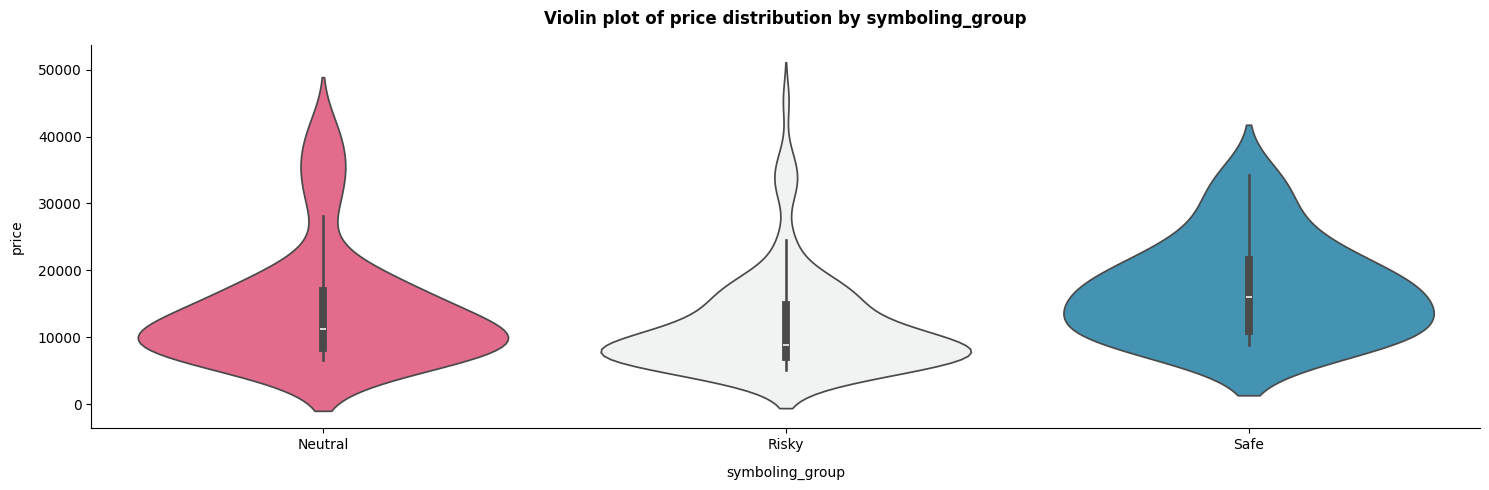

,fueltype,Count,Mean_target_feature,Median_target_feature,Std_target_feature
0,diesel,20,15838.150000,13852.500000,7759.843713
1,gas,185,12999.798200,9989.000000,7984.409306


🔎 D’Agostino and Pearson Normality Test for 'price' across 'fueltype' groups

 Group: gas (n = 185)
  Statistic : 79.308
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: diesel (n = 20)
  Statistic : 2.426
  p-value   : 0.29736
  🟢 Interpretation: Data appears to follow a normal distribution.

🔍 Mann–Whitney U Test for 'price' by 'fueltype'

H₀: The distributions of the two groups are equal.
H₁: The distributions are different.

U statistic : 1347.0
p-value     : 0.04616736846226526

✅ Result: Statistically significant difference between the two groups (Reject H₀).
 Interpretation: Group 'diesel' has a higher median 'price' than Group 'gas'.


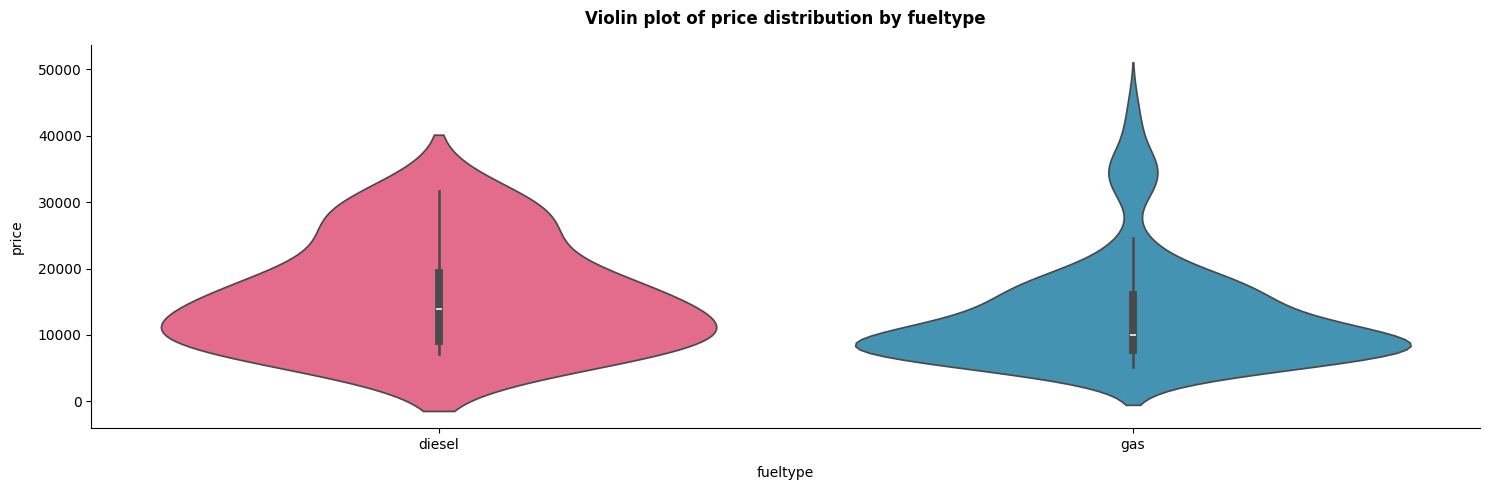

,aspiration,Count,Mean_target_feature,Median_target_feature,Std_target_feature
1,turbo,37,16298.166676,16503.000000,6098.889385
0,std,168,12611.270833,9418.000000,8214.342183


🔎 D’Agostino and Pearson Normality Test for 'price' across 'aspiration' groups

 Group: std (n = 168)
  Statistic : 78.426
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: turbo (n = 37)
  Statistic : 2.881
  p-value   : 0.23685
  🟢 Interpretation: Data appears to follow a normal distribution.

🔍 Mann–Whitney U Test for 'price' by 'aspiration'

H₀: The distributions of the two groups are equal.
H₁: The distributions are different.

U statistic : 1666.5
p-value     : 1.027454898989684e-05

✅ Result: Statistically significant difference between the two groups (Reject H₀).
 Interpretation: Group 'turbo' has a higher median 'price' than Group 'std'.


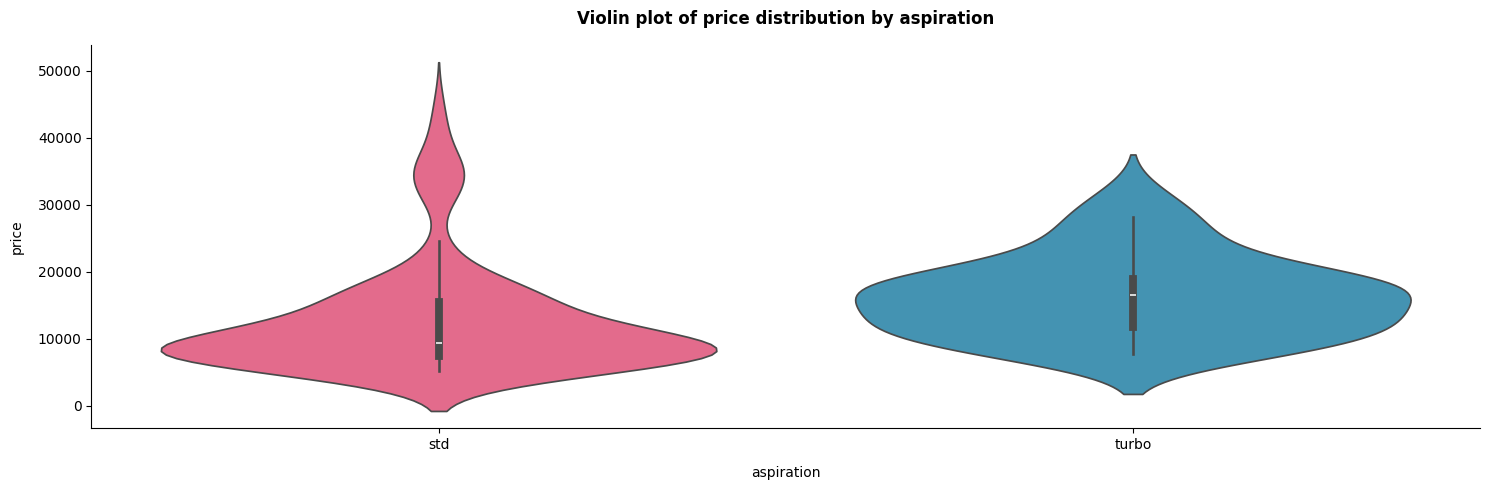

,doornumber,Count,Mean_target_feature,Median_target_feature,Std_target_feature
0,four,115,13501.152174,10898.000000,7338.296321
1,two,90,12989.924078,9927.000000,8784.227805


🔎 D’Agostino and Pearson Normality Test for 'price' across 'doornumber' groups

 Group: two (n = 90)
  Statistic : 42.659
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: four (n = 115)
  Statistic : 42.205
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

🔍 Mann–Whitney U Test for 'price' by 'doornumber'

H₀: The distributions of the two groups are equal.
H₁: The distributions are different.

U statistic : 4462.0
p-value     : 0.09096288374664191

⚪ Result: No statistically significant difference between the two groups (Fail to reject H₀).


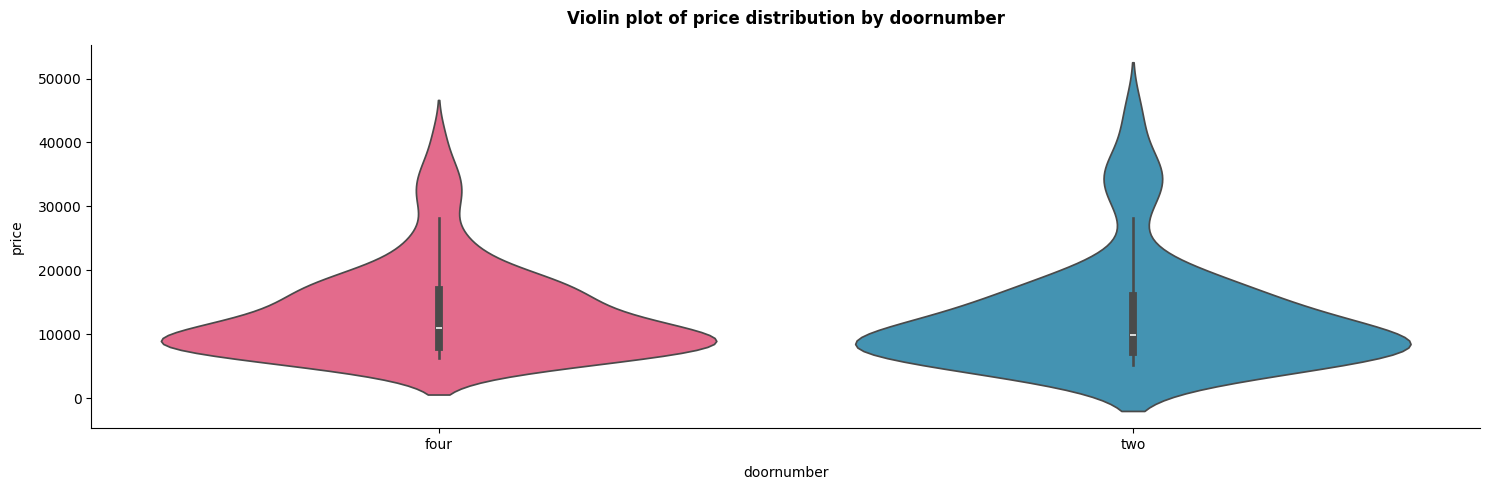

,carbody,Count,Mean_target_feature,Median_target_feature,Std_target_feature
0,Other,39,15854.102564,12440.000000,9710.336424
2,sedan,96,14344.270833,10846.500000,8470.487812
1,hatchback,70,10376.652386,8897.000000,4909.641988


🔎 D’Agostino and Pearson Normality Test for 'price' across 'carbody' groups

 Group: Other (n = 39)
  Statistic : 14.949
  p-value   : 0.00057
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: hatchback (n = 70)
  Statistic : 31.162
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: sedan (n = 96)
  Statistic : 31.122
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.


🔍 Kruskal-Wallis Test: price ~ carbody
Kruskal-Wallis H-statistic: 17.326
p-value: 0.00017284547809408288
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
              Other  hatchback     sedan
Other      1.000000   0.000894  1.000000
hatchback  0.000894   1.000000  0.001506
sedan      1.000000   0.001506  1.000000


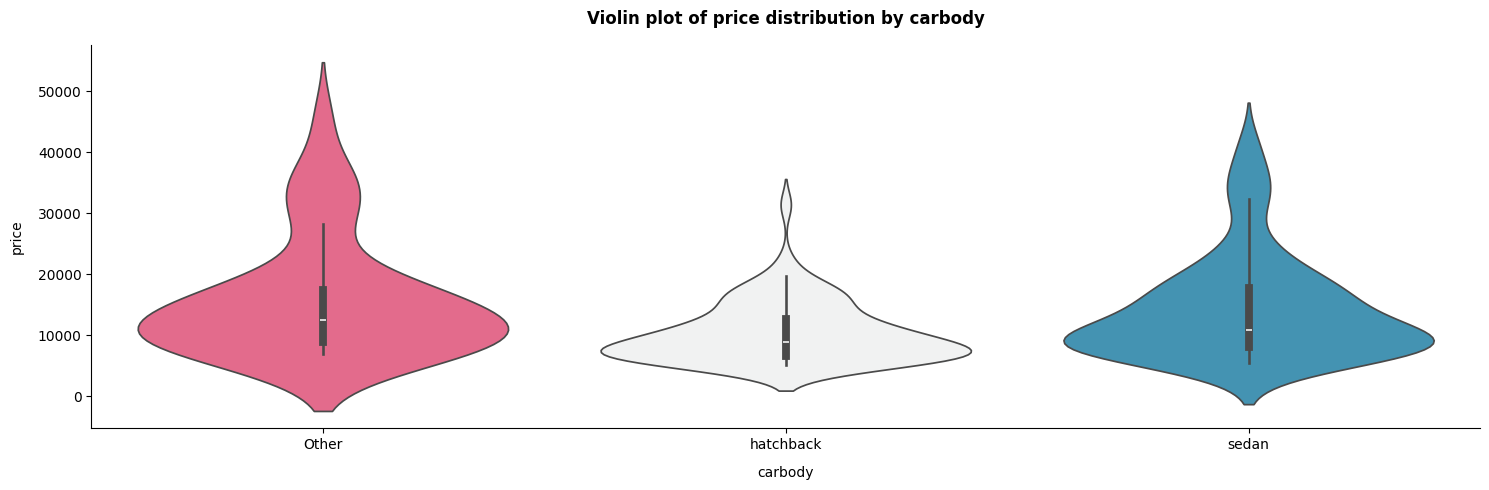

,drivewheel,Count,Mean_target_feature,Median_target_feature,Std_target_feature
2,rwd,76,19910.809211,16912.500000,9120.137883
0,Other,9,11087.463000,9233.000000,3988.644756
1,fwd,120,9239.308333,8222.000000,3317.930730


🔎 D’Agostino and Pearson Normality Test for 'price' across 'drivewheel' groups

 Group: rwd (n = 76)
  Statistic : 10.615
  p-value   : 0.00495
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: fwd (n = 120)
  Statistic : 45.658
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: Other (n = 9)
  Statistic : 2.504
  p-value   : 0.28592
  🟢 Interpretation: Data appears to follow a normal distribution.


🔍 Kruskal-Wallis Test: price ~ drivewheel
Kruskal-Wallis H-statistic: 95.024
p-value: 2.3218205980562865e-21
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
          Other           fwd           rwd
Other  1.000000  5.305357e-01  1.909397e-02
fwd    0.530536  1.000000e+00  5.832629e-22
rwd    0.019094  5.832629e-22  1.000000e+00


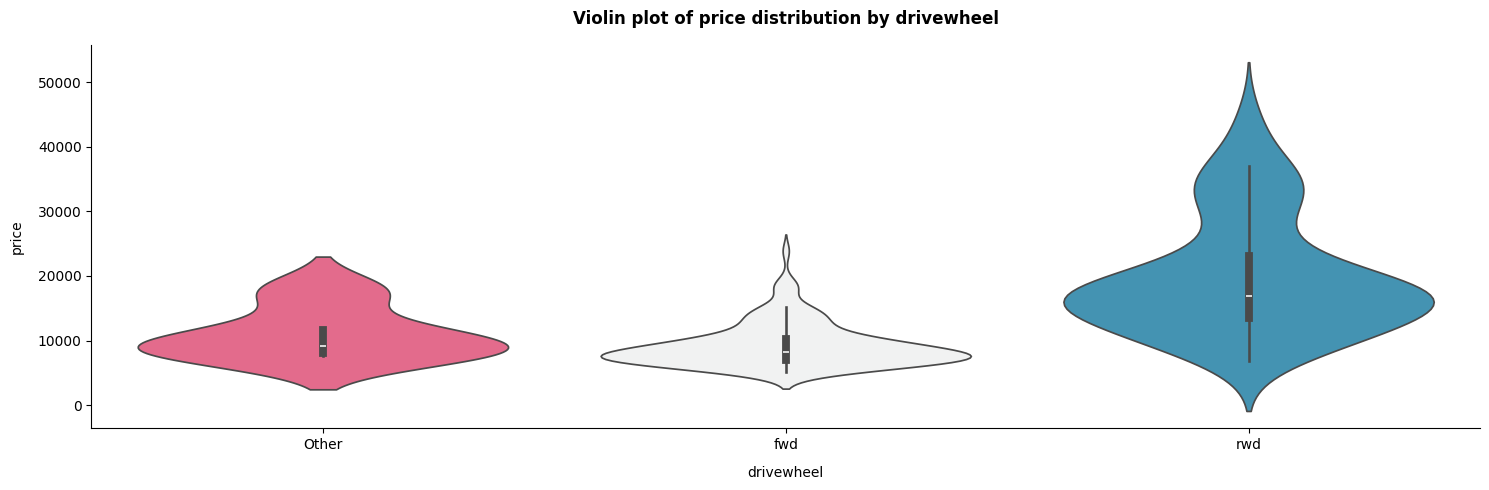

,enginetype,Count,Mean_target_feature,Median_target_feature,Std_target_feature
0,Other,57,17697.657895,15690.000000,9856.703797
1,ohc,148,11574.048426,9022.000000,6407.833422


🔎 D’Agostino and Pearson Normality Test for 'price' across 'enginetype' groups

 Group: Other (n = 57)
  Statistic : 11.967
  p-value   : 0.00252
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: ohc (n = 148)
  Statistic : 72.318
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

🔍 Mann–Whitney U Test for 'price' by 'enginetype'

H₀: The distributions of the two groups are equal.
H₁: The distributions are different.

U statistic : 6113.5
p-value     : 6.369354562037379e-07

✅ Result: Statistically significant difference between the two groups (Reject H₀).
 Interpretation: Group 'Other' has a higher median 'price' than Group 'ohc'.


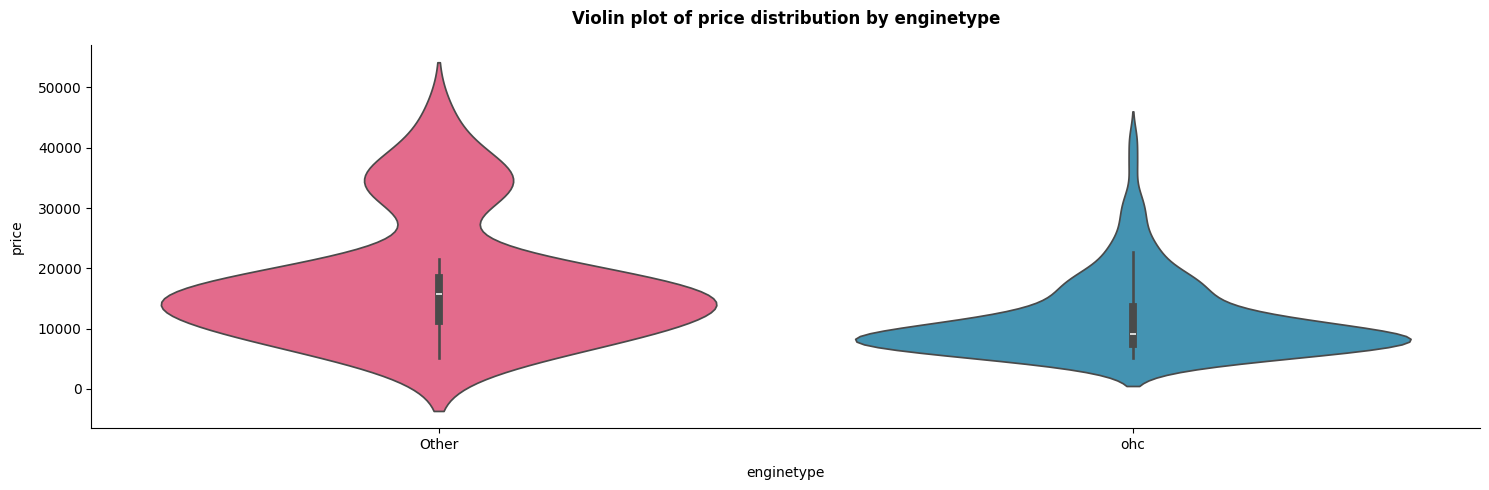

,cylindernumber,Count,Mean_target_feature,Median_target_feature,Std_target_feature
2,six,24,23671.833333,21037.500000,8850.138258
0,Other,22,23553.030318,21397.500000,10799.532299
1,four,159,10285.754717,8948.000000,3921.610470


🔎 D’Agostino and Pearson Normality Test for 'price' across 'cylindernumber' groups

 Group: four (n = 159)
  Statistic : 22.350
  p-value   : 0.00001
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: six (n = 24)
  Statistic : 4.695
  p-value   : 0.09560
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: Other (n = 22)
  Statistic : 1.377
  p-value   : 0.50225
  🟢 Interpretation: Data appears to follow a normal distribution.


🔍 Kruskal-Wallis Test: price ~ cylindernumber
Kruskal-Wallis H-statistic: 73.442
p-value: 1.1278313381099947e-16
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
              Other          four           six
Other  1.000000e+00  1.121425e-08  1.000000e+00
four   1.121425e-08  1.000000e+00  1.409473e-11
six    1.000000e+00  1.409473e-11  1.000000e+00


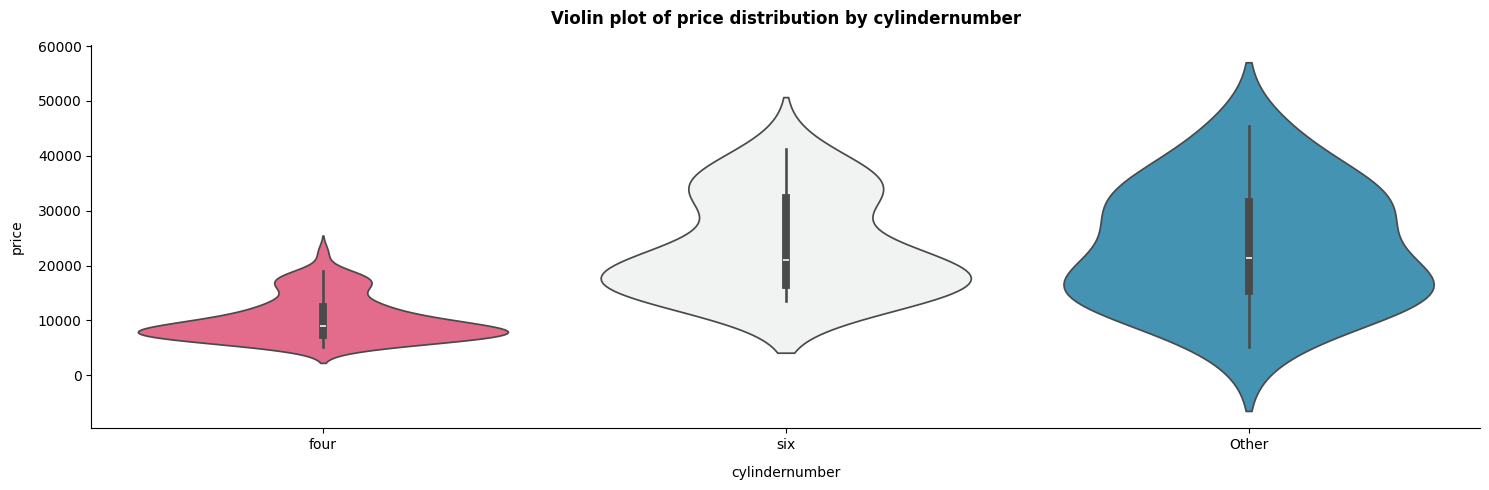

,fuelsystem,Count,Mean_target_feature,Median_target_feature,Std_target_feature
2,mpfi,94,17754.602840,15991.500000,8685.893626
1,Other,45,12427.444444,10698.000000,6292.296616
0,2bbl,66,7478.151515,7372.000000,1385.361935


🔎 D’Agostino and Pearson Normality Test for 'price' across 'fuelsystem' groups

 Group: mpfi (n = 94)
  Statistic : 25.603
  p-value   : 0.00000
  🔴 Interpretation: Data does not appear to follow a normal distribution.

 Group: 2bbl (n = 66)
  Statistic : 2.438
  p-value   : 0.29554
  🟢 Interpretation: Data appears to follow a normal distribution.

 Group: Other (n = 45)
  Statistic : 18.434
  p-value   : 0.00010
  🔴 Interpretation: Data does not appear to follow a normal distribution.


🔍 Kruskal-Wallis Test: price ~ fuelsystem
Kruskal-Wallis H-statistic: 110.675
p-value: 9.27284541399061e-25
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               2bbl     Other          mpfi
2bbl   1.000000e+00  0.000002  2.132304e-25
Other  2.093007e-06  1.000000  1.698507e-04
mpfi   2.132304e-25  0.000170  1.000000e+00


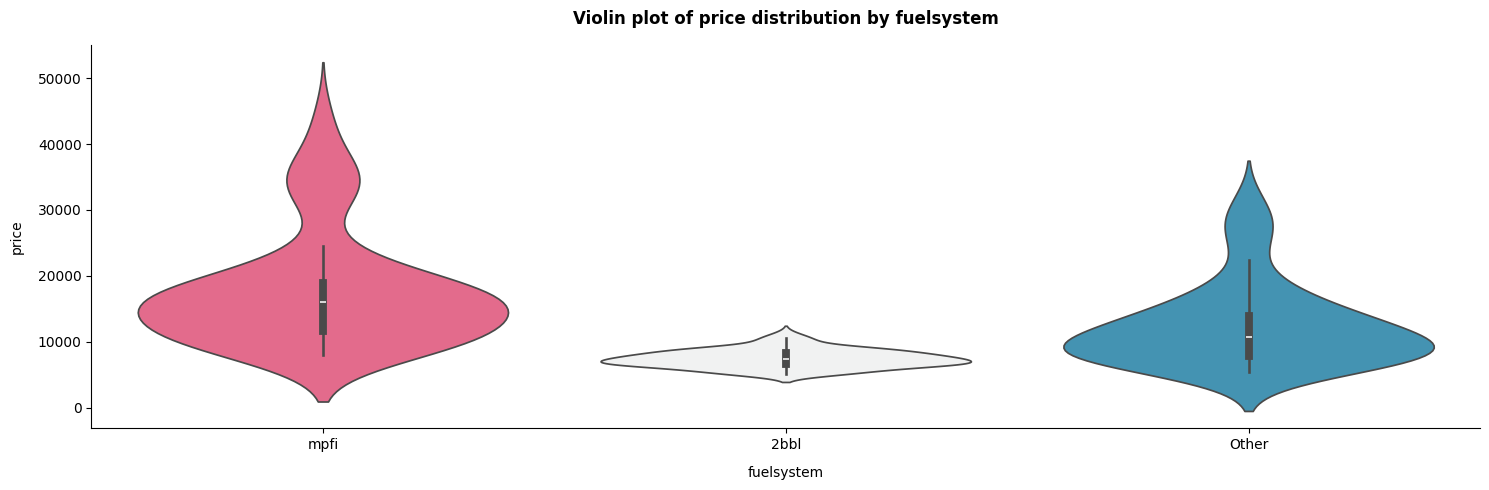

In [55]:
from IPython.core.display import HTML
target_feature = "price"
def perform_statical_testing(total_categories, feature, df_train = df, target_feature = target_feature):
    cal_normaltest(cat_feature=feature, num_feature=target_feature, df=df_train)
    if total_categories == 2:
        cal_mannwhitneyu(dataframe=df_train, categorical_feature=feature, num_feature=target_feature)
    else:
        perform_kruskal_test(df=df_train, categorical_feature=feature, numeric_feature=target_feature)

def plot_categorical_distribution_by_target_feature(feature, df_train = df, target_feature = target_feature, order = None):
    """
    Performs statical testing for each groups (distribution by target_feature) by ANOVA, T-test, Mann-Whitney U test,... <br>
    Draw violin and histogram to display the distribution for each groups of feature.
    Parameters:
        feature (str): The name of the column representing the grouping variable (categorical).
        df_train (pd.DataFrame): The input dataset.
        target_feature (str): The name of the column representing the target feature.
        order (list): Order items in plot.

    Returns:
        None
    """

    # Summary information
    df_summary_feature = df_train.groupby(by = feature, as_index= False)\
    .agg (
        Count = (target_feature, "count"),
        Mean_target_feature = (target_feature, "mean"),
        Median_target_feature = (target_feature, "median"),
        Std_target_feature = (target_feature, "std")
    )
    df_summary_feature = df_summary_feature.sort_values(by="Mean_target_feature", ascending=False)    

    summary_data = [
        ("Total Categories", f"{df_summary_feature.shape[0]}"),
        ("Overall Target Mean", f"{df_train[target_feature].mean():.2f}")
    ]
    summary_html = "<ul>" + "".join([f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data]) + "</ul>"
    display(HTML(summary_html))
    display(df_summary_feature.style.background_gradient(cmap=cm).set_table_attributes('style="width:75%; margin:auto;"'))

    perform_statical_testing(total_categories=df_summary_feature.shape[0], 
                             feature=feature, df_train=df_train, target_feature=target_feature)

    # Plot distribution
    fig, ax = plt.subplots(figsize=(15, 5))
    sns.violinplot(x=feature, y=target_feature, data=df_train, hue=feature, 
                palette=color(n_colors=df_train[feature].nunique()), ax=ax)
    ax.set_title(f"Violin plot of {target_feature} distribution by {feature}", pad=15, weight = "bold")
    ax.set_xlabel(feature, labelpad=10)
    ax.set_ylabel(target_feature, labelpad=10)
    # plt.grid(axis="y", color="gray", linestyle=":", alpha=0.7)
    sns.despine(left=False, bottom=False, ax=ax)

    plt.tight_layout()
    plt.show()

for feature in cat_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {target_feature} by {feature}</b></h2>"))
    plot_categorical_distribution_by_target_feature(feature=feature)